## 1. Import dependencies

In [19]:
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## 2. Configure random seed, device and data path

In [ ]:
SEED = 38 #random seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# dataset directory
DATASET_DIR = Path("./chest_xray")
# DATASET_DIR = Path("/kaggle/input/datasets/zhichongwang38/ml1-project/main/chest_xray") //for kaggle use

# image format
IMG_EXTENSIONS = {".jpeg", ".jpg"}

# output directories
OUTPUT_DIR = Path("./outputs")
MODEL_DIR = Path("./models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# training config
IMAGE_SIZE = 224 # image resizing (as preprocessing)
BATCH_SIZE = 64 # batch size
NUM_EPOCHS = 16 # epochs number
LEARNING_RATE = 1e-4 # initial learning rate
WEIGHT_DECAY = 1e-4 # decoupled weight decay for AdamW optimizer
LR_STEP_SIZE = 4 # learning rate decays every 4 epochs
LR_GAMMA = 0.5 # each learning rate decay reduces to 0.5 of the previous value
NUM_WORKERS = 2

# labels mapping: NORMAL=0, PNEUMONIA=1
CLASS_TO_IDX = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# device selection (cuda or mps or cpu)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda") # for kaggle use
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # for MacBook (M chip) use
else:
    DEVICE = torch.device("cpu") # otherwise

print("DATASET_DIR =", DATASET_DIR.resolve())
print("OUTPUT_DIR =", OUTPUT_DIR.resolve())
print("MODEL_DIR =", MODEL_DIR.resolve())
print("DEVICE =", DEVICE)

DATASET_DIR = /Users/wangzhichong/ML_HW/project/main/chest_xray
OUTPUT_DIR = /Users/wangzhichong/ML_HW/project/main/outputs
MODEL_DIR = /Users/wangzhichong/ML_HW/project/main/models
DEVICE = mps


## 3. Count the number of images in each subfolder

In [21]:
def list_images_in_dir(folder: Path):
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS
    ])

def count_images(dataset_dir: Path):
    stats = {}
    for split in ["train", "val", "test"]:
        stats[split] = {}
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_dir = dataset_dir / split / cls
            stats[split][cls] = len(list_images_in_dir(cls_dir))
    return stats

stats = count_images(DATASET_DIR)
stats

{'train': {'NORMAL': 1140, 'PNEUMONIA': 3294},
 'val': {'NORMAL': 209, 'PNEUMONIA': 589},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

## 4. Visualized sample images

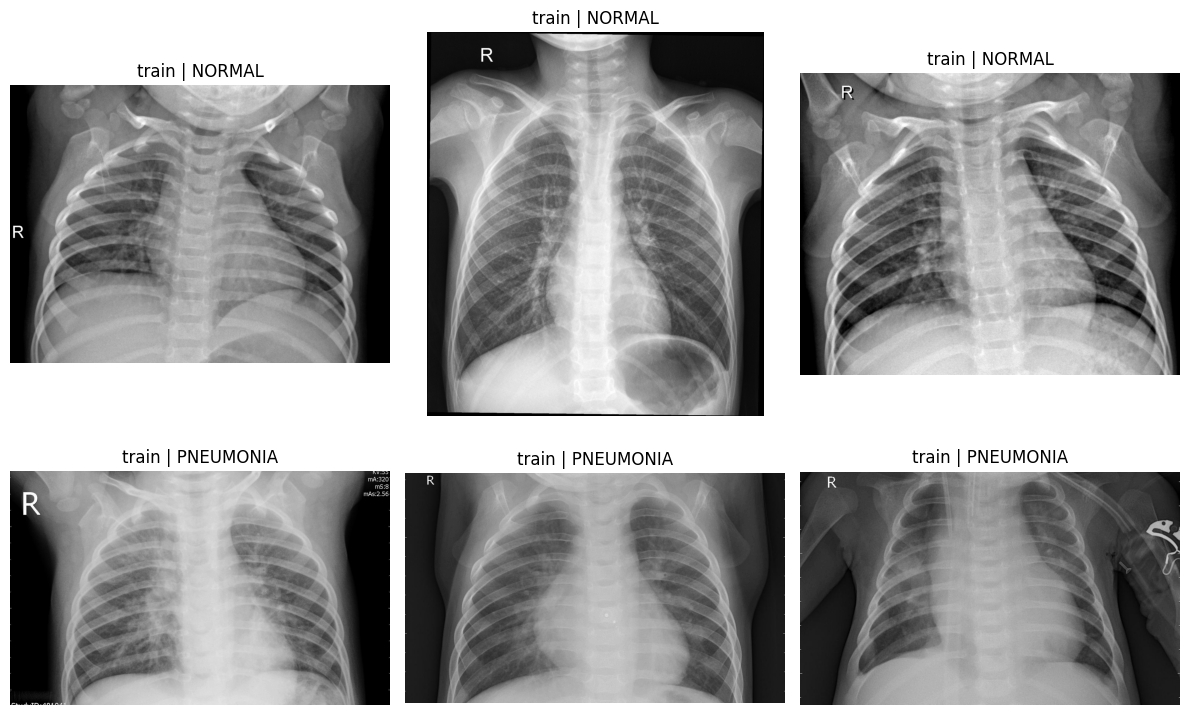

In [ ]:
def show_random_samples(dataset_dir: Path, split="train", n_per_class=3, save_path=None):
    fig, axes = plt.subplots(2, n_per_class, figsize=(4 * n_per_class, 8))
    classes = ["NORMAL", "PNEUMONIA"]

    for row, cls in enumerate(classes):
        img_paths = list_images_in_dir(dataset_dir / split / cls)
        chosen = random.sample(img_paths, min(n_per_class, len(img_paths)))

        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis("off")

            if col < len(chosen):
                img = Image.open(chosen[col]).convert("L")
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{split} | {cls}")

    plt.tight_layout()
    plt.show()

show_random_samples(DATASET_DIR, split="train", n_per_class=3, save_path=OUTPUT_DIR / "sample_images.png")

## 5. Define data augmentation and data preprocessing

> Training set use light augmentation：
> - small angle random rotation
> - slight random translation
> - slight brightness adjustment
> - slight contrast adjustment

In [ ]:
# training set uses lightweight data augmentation, and single-channel data is copied to three channels
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # copy one channel to a three channels format
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # resize to 224*224
    transforms.RandomRotation(degrees=8), # rotation, data augmentation
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # affine
    transforms.ColorJitter(brightness=0.10, contrast=0.10), # color adjust
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # normalized
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # copy one channel to a three channels format
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # resize to 224*224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # normalized
])

## 6. Building Dataset and DataLoader

In [ ]:
# construct dataset and dataloader
train_dataset = datasets.ImageFolder(DATASET_DIR / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_DIR / "val", transform=eval_transform)
test_dataset = datasets.ImageFolder(DATASET_DIR / "test", transform=eval_transform)

print("ImageFolder class_to_idx:", train_dataset.class_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

ImageFolder class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


## 7. Handle class imbalance and building ResNet18 networks by hand

> Use **class-weighted cross-entropy loss**  
> ResNet18 is implemented manually using PyTorch：
> - The last layer is changed to 2-class output


In [ ]:
# get class weights function (used in later class-weighted cross-entropy loss)
def compute_class_weights(imagefolder_dataset):
    targets = np.array(imagefolder_dataset.targets)
    class_counts = np.bincount(targets)
    class_weights = len(targets) / (len(class_counts) * class_counts)
    return class_counts, class_weights.astype(np.float32)

train_class_counts, class_weights = compute_class_weights(train_dataset)

print("Train class counts:", train_class_counts)
print("Class weights:", class_weights)


# ResNet18 basic residual block
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # main: Conv-BN-ReLU-Conv-BN
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut branch: align with a 1*1 conv when the size or number of channels changes
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x): # forward function
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # residual connection: F(x) + x
        out = out + identity
        out = self.relu(out)
        return out


# RestNet 18 network ([2, 2, 2, 2])
class ResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.in_channels = 64

        # input layer: 3-channel, 7*7 conv, stride 2
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # four stages, every stage has 2 basic block
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride=stride))
        self.in_channels = out_channels * BasicBlock.expansion

        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        # initilization: Conv use Kaiming Normal，the scale of BN is set to 1
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): # forward function
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = ResNet18(num_classes=2).to(DEVICE)

criterion = nn.CrossEntropyLoss( # class-weighted cross-entropy loss
    weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.AdamW( # AdamW optimizer
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.StepLR( # learning rate decay
    optimizer,
    step_size=LR_STEP_SIZE,
    gamma=LR_GAMMA
)

print(model)

Train class counts: [1140 3294]
Class weights: [1.9447368 0.6730419]
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64,

## 8. Define training and evaluation functions

In [ ]:
# train one epoch function
def run_one_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images) # forward pass
            loss = criterion(logits, labels) # compute loss

            if is_train:
                loss.backward() # backward pass
                optimizer.step() # update

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# predict function (use on later test set)
@torch.no_grad()
def predict_with_scores(model, loader, device=DEVICE):
    model.eval()

    all_logits = []
    all_probs = []
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1) # probability

        preds = torch.argmax(probs, dim=1)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels)

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return all_labels, all_preds, all_probs, all_logits

## 9. Train the model and save the best model based on the accuracy on the validation set

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = -1.0
best_epoch = -1

start_time = time.time()

for epoch in range(NUM_EPOCHS): # train epoch times
    t0 = time.time()

    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer, DEVICE) # train on training set
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE) # evaluate on val set

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    dt = time.time() - t0

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | time={dt:.1f}s"
    )

    if val_acc > best_val_acc: # store the best model according to val acc
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())

    # learning rate decay
    scheduler.step()

elapsed = time.time() - start_time
print(f"Training finished in {elapsed / 60:.2f} min")
print(f"Best Val Acc: {best_val_acc:.4f} (Epoch {best_epoch})")

model.load_state_dict(best_model_wts) # load the best model weights

Epoch [01/16] | LR: 0.000100 | Train Loss: 0.2759 | Train Acc: 0.8735 | Val Loss: 0.2074 | Val Acc: 0.9474 | time=51.1s
Epoch [02/16] | LR: 0.000100 | Train Loss: 0.1333 | Train Acc: 0.9434 | Val Loss: 0.3217 | Val Acc: 0.9211 | time=48.4s
Epoch [03/16] | LR: 0.000100 | Train Loss: 0.1087 | Train Acc: 0.9576 | Val Loss: 0.1635 | Val Acc: 0.9323 | time=47.3s
Epoch [04/16] | LR: 0.000100 | Train Loss: 0.1004 | Train Acc: 0.9635 | Val Loss: 0.1329 | Val Acc: 0.9586 | time=47.2s
Epoch [05/16] | LR: 0.000050 | Train Loss: 0.0828 | Train Acc: 0.9693 | Val Loss: 0.1195 | Val Acc: 0.9599 | time=47.6s
Epoch [06/16] | LR: 0.000050 | Train Loss: 0.0743 | Train Acc: 0.9734 | Val Loss: 0.1261 | Val Acc: 0.9662 | time=48.0s
Epoch [07/16] | LR: 0.000050 | Train Loss: 0.0685 | Train Acc: 0.9754 | Val Loss: 0.1369 | Val Acc: 0.9649 | time=47.8s
Epoch [08/16] | LR: 0.000050 | Train Loss: 0.0725 | Train Acc: 0.9714 | Val Loss: 0.0829 | Val Acc: 0.9737 | time=49.0s
Epoch [09/16] | LR: 0.000025 | Train Los

<All keys matched successfully>

## 10. Plot training curves

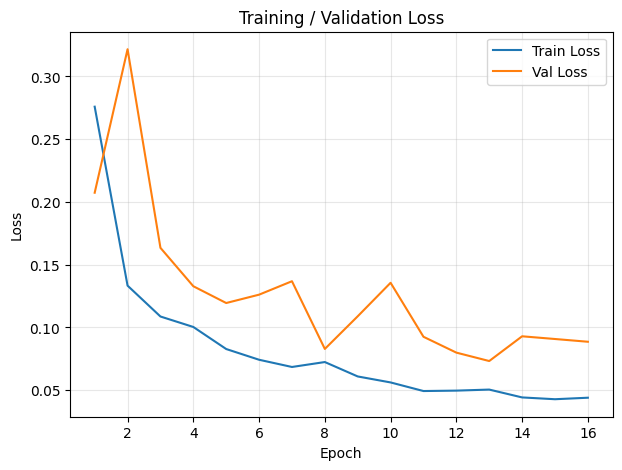

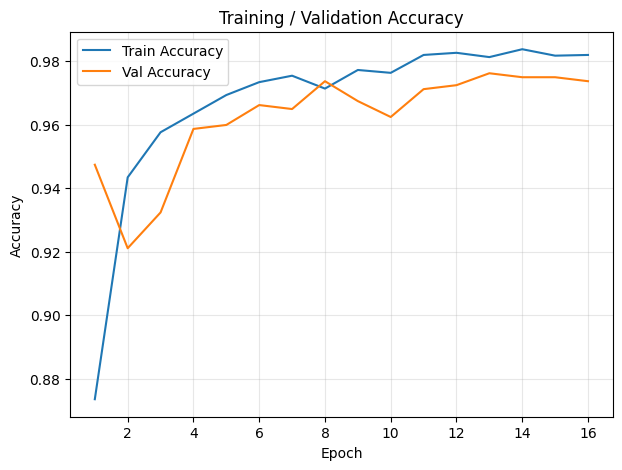

In [ ]:
epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "resnet18_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "resnet18_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Evaluate the best model on the test set

> - Accuracy
> - Classification Report
> - Confusion Matrix
> - ROC-AUC
> - ROC Curve

In [ ]:
# test on test set
y_test, test_pred, test_probs, test_logits = predict_with_scores(model, test_loader, DEVICE)

# probability of the positive class (PNEUMONIA) is used as the input to the ROC-AUC
test_scores = test_probs[:, 1]

test_acc = accuracy_score(y_test, test_pred) #test acc
test_roc_auc = roc_auc_score(y_test, test_scores) #test auc

print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))

Test Accuracy: 0.8654
Test ROC-AUC: 0.9626


In [30]:
print("Classification Report: (ResNet18 from scratch)")
print(classification_report(
    y_test,
    test_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    digits=4
))

Classification Report: (ResNet18 from scratch)
              precision    recall  f1-score   support

      NORMAL     0.9870    0.6496    0.7835       234
   PNEUMONIA     0.8255    0.9949    0.9023       390

    accuracy                         0.8654       624
   macro avg     0.9063    0.8222    0.8429       624
weighted avg     0.8861    0.8654    0.8578       624



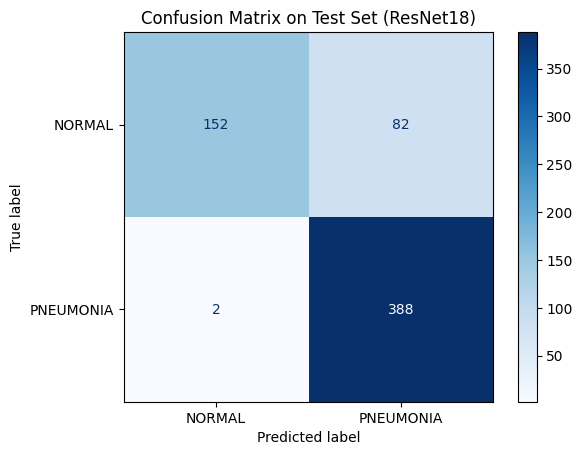

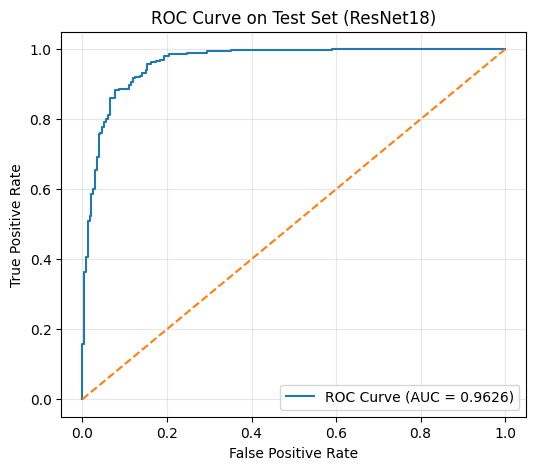

Confusion matrix saved to: /Users/wangzhichong/ML_HW/project/main/outputs/resnet18_confusion_matrix.png
ROC curve saved to: /Users/wangzhichong/ML_HW/project/main/outputs/resnet18_roc_curve.png


In [ ]:
# plot confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set (ResNet18)")
plt.savefig(OUTPUT_DIR / "resnet18_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (ResNet18)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "resnet18_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", (OUTPUT_DIR / "resnet18_confusion_matrix.png").resolve())
print("ROC curve saved to:", (OUTPUT_DIR / "resnet18_roc_curve.png").resolve())

## 12. Observe the samples with incorrect predictions

In [ ]:
# reconstruct a dataset without random augmentation and with return paths for visualization of incorrect predictions
class ChestXrayWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path = self.samples[index][0]
        return image, label, path

test_vis_dataset = ChestXrayWithPaths(DATASET_DIR / "test", transform=eval_transform)
test_vis_loader = DataLoader(
    test_vis_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

# collect misclassified samples function
@torch.no_grad()
def collect_misclassified_samples(model, loader, device=DEVICE):
    model.eval()
    results = []

    for images, labels, paths in loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        labels = labels.numpy()

        for i in range(len(paths)):
            if preds[i] != labels[i]:
                results.append((paths[i], labels[i], preds[i]))
    return results

misclassified = collect_misclassified_samples(model, test_vis_loader, DEVICE)
print("Number of misclassified samples:", len(misclassified))

Number of misclassified samples: 84


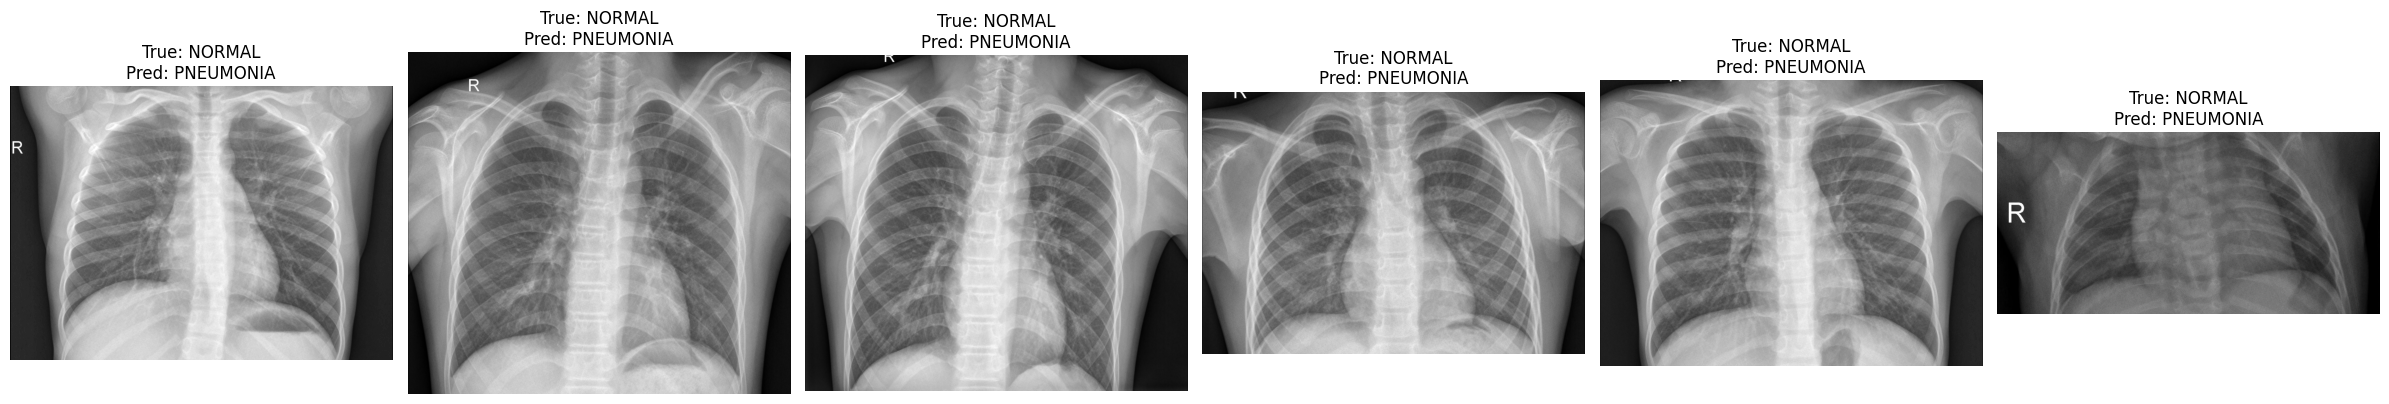

In [ ]:
# show misclassified samples function
def show_misclassified_samples(misclassified, n=6):
    if len(misclassified) == 0:
        print("No misclassified samples.")
        return

    chosen = misclassified[:min(n, len(misclassified))]
    fig, axes = plt.subplots(1, len(chosen), figsize=(4 * len(chosen), 4))
    if len(chosen) == 1:
        axes = [axes]

    for ax, (img_path, true_label, pred_label) in zip(axes, chosen):
        img = Image.open(img_path).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(f"True: {IDX_TO_CLASS[true_label]}\nPred: {IDX_TO_CLASS[pred_label]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_samples(misclassified, n=6)

## 13. Save the best model

> The model save to `models/`  
> Images results save to `outputs/`


In [34]:
model_path = MODEL_DIR / "resnet18_from_scratch_best.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": CLASS_TO_IDX,
    "image_size": IMAGE_SIZE,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_acc": test_acc,
    "test_roc_auc": test_roc_auc,
}, model_path)

print("Best model has been saved to:", model_path.resolve())

Best model has been saved to: /Users/wangzhichong/ML_HW/project/main/models/resnet18_from_scratch_best.pth
